In [101]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn import metrics
from mlxtend.plotting import plot_confusion_matrix
from sklearn.model_selection import StratifiedKFold

In [102]:
df = pd.read_csv("Iris.csv")
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [103]:
X = df[['SepalLengthCm',
        'SepalWidthCm',
        'PetalLengthCm',
        'PetalWidthCm']].values
Y = df['Species'].values

In [104]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [105]:
def evaluate_model(model, X, Y):

    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=2)

    acc_scores = []
    precision_scores = []
    recall_scores = []
    f1_scores = []

    for fold, (train_index, test_index) in enumerate(skf.split(X, Y), 1):

        print("\n")
        print("Fold:", fold)


        X_train = X[train_index]
        X_test = X[test_index]

        Y_train = Y[train_index]
        Y_test = Y[test_index]

        model.fit(X_train, Y_train)

        Y_pred = model.predict(X_test)

        acc = metrics.accuracy_score(Y_test, Y_pred)
        precision = metrics.precision_score(Y_test, Y_pred, average='macro')
        recall = metrics.recall_score(Y_test, Y_pred, average='macro')
        f1 = metrics.f1_score(Y_test, Y_pred, average='macro')

        print("Accuracy      :", round(acc, 4))
        print("Precision     :", round(precision, 4))
        print("Recall        :", round(recall, 4))
        print("F1 Score      :", round(f1, 4))

        acc_scores.append(acc)
        precision_scores.append(precision)
        recall_scores.append(recall)
        f1_scores.append(f1)

        cm = metrics.confusion_matrix(Y_test, Y_pred)

        print("\nConfusion Matrix:")

        plot_confusion_matrix(conf_mat=cm)
        plt.title(f"Confusion Matrix - Fold {fold}")
        plt.show()

        print("\nClassification Report:")
        print(metrics.classification_report(Y_test, Y_pred))

    print("FINAL")

    print("Average Accuracy  :", round(np.mean(acc_scores), 4))
    print("Average Precision :", round(np.mean(precision_scores), 4))
    print("Average Recall    :", round(np.mean(recall_scores), 4))
    print("Average F1 Score  :", round(np.mean(f1_scores), 4))



Fold: 1
Accuracy      : 0.8667
Precision     : 0.8667
Recall        : 0.8667
F1 Score      : 0.8667

Confusion Matrix:


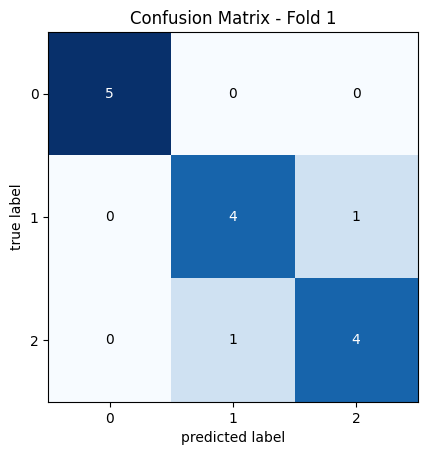


Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         5
Iris-versicolor       0.80      0.80      0.80         5
 Iris-virginica       0.80      0.80      0.80         5

       accuracy                           0.87        15
      macro avg       0.87      0.87      0.87        15
   weighted avg       0.87      0.87      0.87        15



Fold: 2
Accuracy      : 0.8667
Precision     : 0.9048
Recall        : 0.8667
F1 Score      : 0.8611

Confusion Matrix:


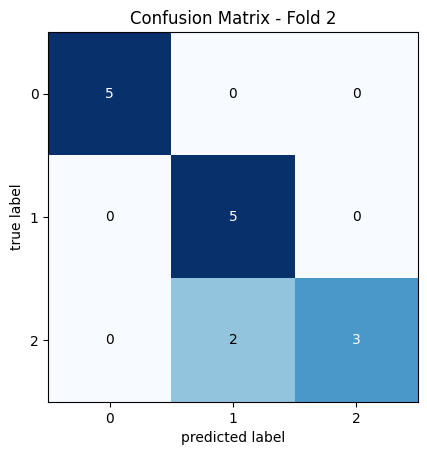


Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         5
Iris-versicolor       0.71      1.00      0.83         5
 Iris-virginica       1.00      0.60      0.75         5

       accuracy                           0.87        15
      macro avg       0.90      0.87      0.86        15
   weighted avg       0.90      0.87      0.86        15



Fold: 3
Accuracy      : 1.0
Precision     : 1.0
Recall        : 1.0
F1 Score      : 1.0

Confusion Matrix:


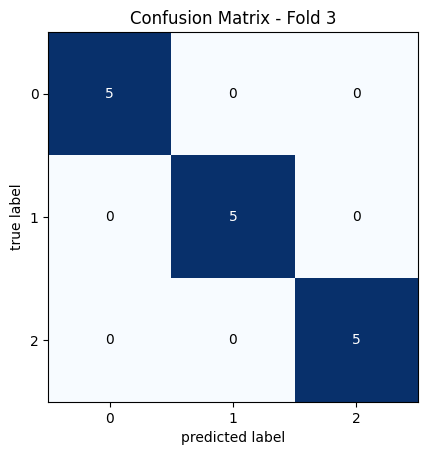


Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         5
Iris-versicolor       1.00      1.00      1.00         5
 Iris-virginica       1.00      1.00      1.00         5

       accuracy                           1.00        15
      macro avg       1.00      1.00      1.00        15
   weighted avg       1.00      1.00      1.00        15



Fold: 4
Accuracy      : 0.9333
Precision     : 0.9444
Recall        : 0.9333
F1 Score      : 0.9327

Confusion Matrix:


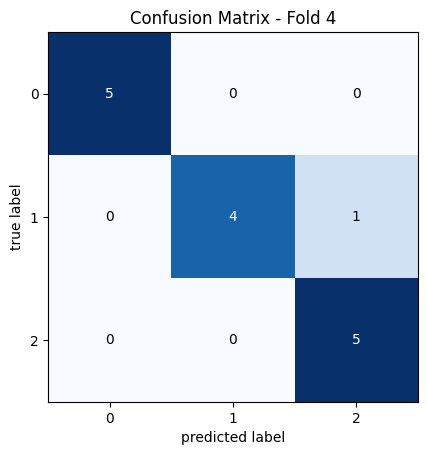


Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         5
Iris-versicolor       1.00      0.80      0.89         5
 Iris-virginica       0.83      1.00      0.91         5

       accuracy                           0.93        15
      macro avg       0.94      0.93      0.93        15
   weighted avg       0.94      0.93      0.93        15



Fold: 5
Accuracy      : 1.0
Precision     : 1.0
Recall        : 1.0
F1 Score      : 1.0

Confusion Matrix:


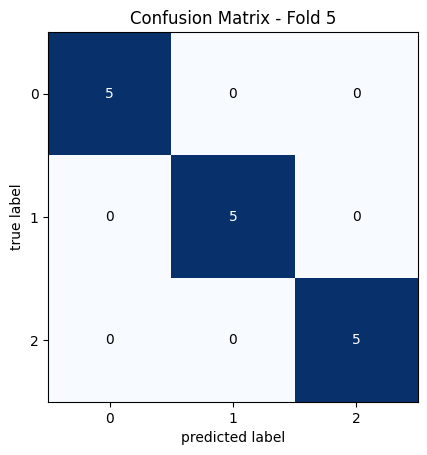


Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         5
Iris-versicolor       1.00      1.00      1.00         5
 Iris-virginica       1.00      1.00      1.00         5

       accuracy                           1.00        15
      macro avg       1.00      1.00      1.00        15
   weighted avg       1.00      1.00      1.00        15



Fold: 6
Accuracy      : 1.0
Precision     : 1.0
Recall        : 1.0
F1 Score      : 1.0

Confusion Matrix:


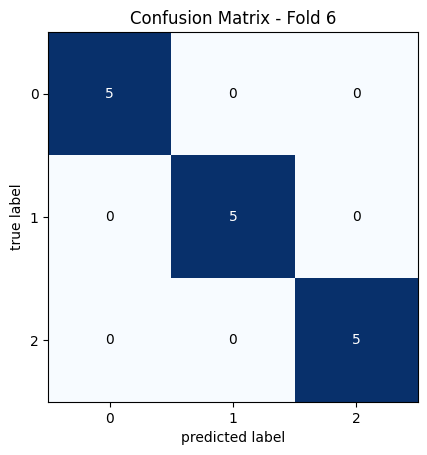


Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         5
Iris-versicolor       1.00      1.00      1.00         5
 Iris-virginica       1.00      1.00      1.00         5

       accuracy                           1.00        15
      macro avg       1.00      1.00      1.00        15
   weighted avg       1.00      1.00      1.00        15



Fold: 7
Accuracy      : 1.0
Precision     : 1.0
Recall        : 1.0
F1 Score      : 1.0

Confusion Matrix:


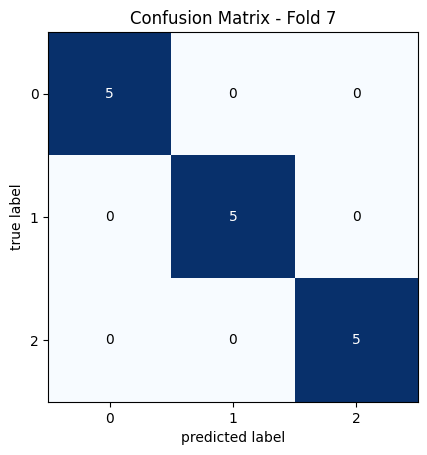


Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         5
Iris-versicolor       1.00      1.00      1.00         5
 Iris-virginica       1.00      1.00      1.00         5

       accuracy                           1.00        15
      macro avg       1.00      1.00      1.00        15
   weighted avg       1.00      1.00      1.00        15



Fold: 8
Accuracy      : 0.9333
Precision     : 0.9444
Recall        : 0.9333
F1 Score      : 0.9327

Confusion Matrix:


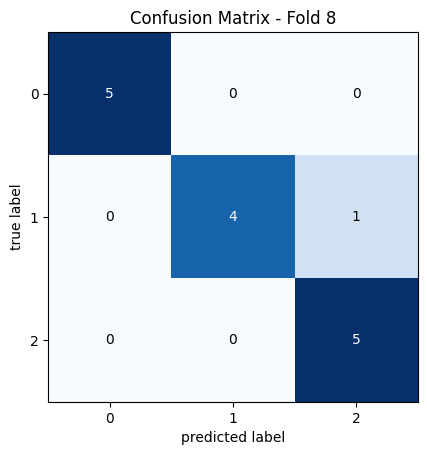


Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         5
Iris-versicolor       1.00      0.80      0.89         5
 Iris-virginica       0.83      1.00      0.91         5

       accuracy                           0.93        15
      macro avg       0.94      0.93      0.93        15
   weighted avg       0.94      0.93      0.93        15



Fold: 9
Accuracy      : 0.9333
Precision     : 0.9444
Recall        : 0.9333
F1 Score      : 0.9327

Confusion Matrix:


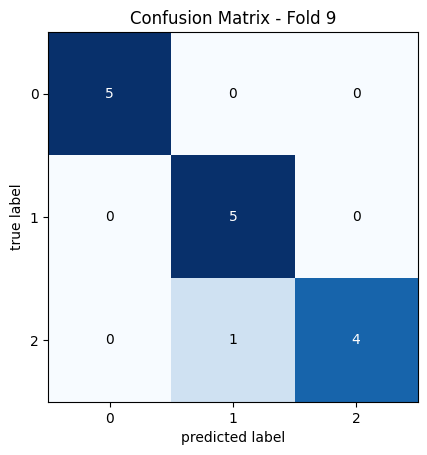


Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         5
Iris-versicolor       0.83      1.00      0.91         5
 Iris-virginica       1.00      0.80      0.89         5

       accuracy                           0.93        15
      macro avg       0.94      0.93      0.93        15
   weighted avg       0.94      0.93      0.93        15



Fold: 10
Accuracy      : 1.0
Precision     : 1.0
Recall        : 1.0
F1 Score      : 1.0

Confusion Matrix:


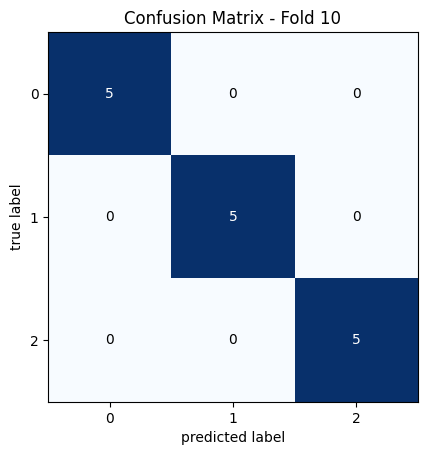


Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         5
Iris-versicolor       1.00      1.00      1.00         5
 Iris-virginica       1.00      1.00      1.00         5

       accuracy                           1.00        15
      macro avg       1.00      1.00      1.00        15
   weighted avg       1.00      1.00      1.00        15

FINAL
Average Accuracy  : 0.9533
Average Precision : 0.9605
Average Recall    : 0.9533
Average F1 Score  : 0.9526


In [106]:
from sklearn.naive_bayes import GaussianNB

model_nb = GaussianNB()
evaluate_model(model_nb, X, Y)


 KNN 


Fold: 1
Accuracy      : 0.9333
Precision     : 0.9444
Recall        : 0.9333
F1 Score      : 0.9327

Confusion Matrix:


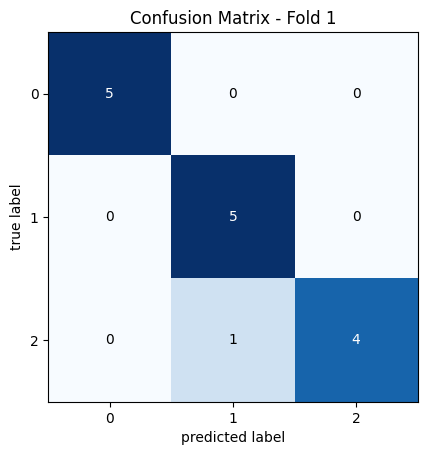


Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         5
Iris-versicolor       0.83      1.00      0.91         5
 Iris-virginica       1.00      0.80      0.89         5

       accuracy                           0.93        15
      macro avg       0.94      0.93      0.93        15
   weighted avg       0.94      0.93      0.93        15



Fold: 2
Accuracy      : 0.8667
Precision     : 0.9048
Recall        : 0.8667
F1 Score      : 0.8611

Confusion Matrix:


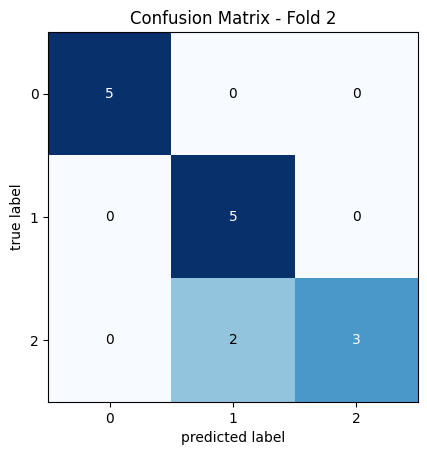


Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         5
Iris-versicolor       0.71      1.00      0.83         5
 Iris-virginica       1.00      0.60      0.75         5

       accuracy                           0.87        15
      macro avg       0.90      0.87      0.86        15
   weighted avg       0.90      0.87      0.86        15



Fold: 3
Accuracy      : 1.0
Precision     : 1.0
Recall        : 1.0
F1 Score      : 1.0

Confusion Matrix:


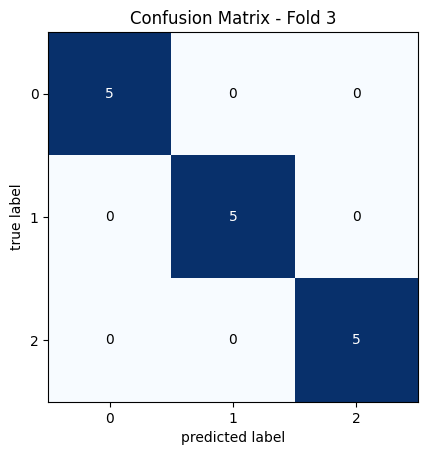


Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         5
Iris-versicolor       1.00      1.00      1.00         5
 Iris-virginica       1.00      1.00      1.00         5

       accuracy                           1.00        15
      macro avg       1.00      1.00      1.00        15
   weighted avg       1.00      1.00      1.00        15



Fold: 4
Accuracy      : 1.0
Precision     : 1.0
Recall        : 1.0
F1 Score      : 1.0

Confusion Matrix:


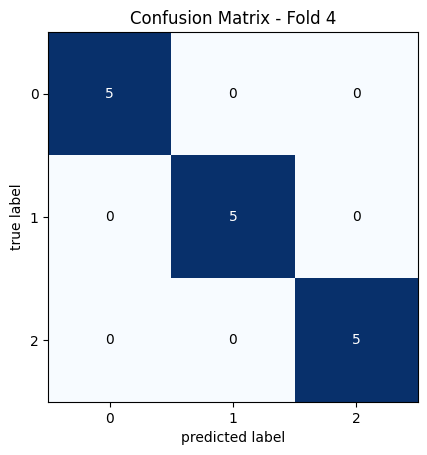


Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         5
Iris-versicolor       1.00      1.00      1.00         5
 Iris-virginica       1.00      1.00      1.00         5

       accuracy                           1.00        15
      macro avg       1.00      1.00      1.00        15
   weighted avg       1.00      1.00      1.00        15



Fold: 5
Accuracy      : 1.0
Precision     : 1.0
Recall        : 1.0
F1 Score      : 1.0

Confusion Matrix:


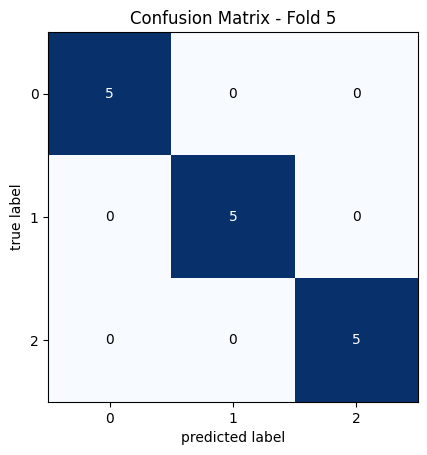


Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         5
Iris-versicolor       1.00      1.00      1.00         5
 Iris-virginica       1.00      1.00      1.00         5

       accuracy                           1.00        15
      macro avg       1.00      1.00      1.00        15
   weighted avg       1.00      1.00      1.00        15



Fold: 6
Accuracy      : 1.0
Precision     : 1.0
Recall        : 1.0
F1 Score      : 1.0

Confusion Matrix:


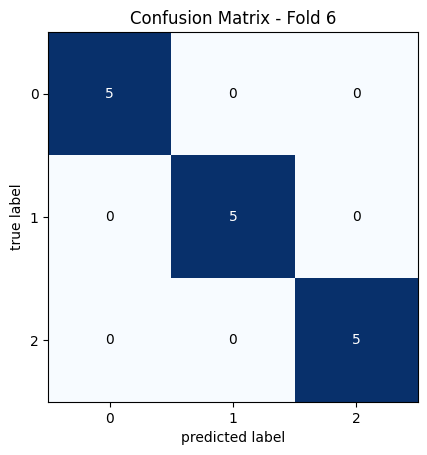


Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         5
Iris-versicolor       1.00      1.00      1.00         5
 Iris-virginica       1.00      1.00      1.00         5

       accuracy                           1.00        15
      macro avg       1.00      1.00      1.00        15
   weighted avg       1.00      1.00      1.00        15



Fold: 7
Accuracy      : 0.9333
Precision     : 0.9444
Recall        : 0.9333
F1 Score      : 0.9327

Confusion Matrix:


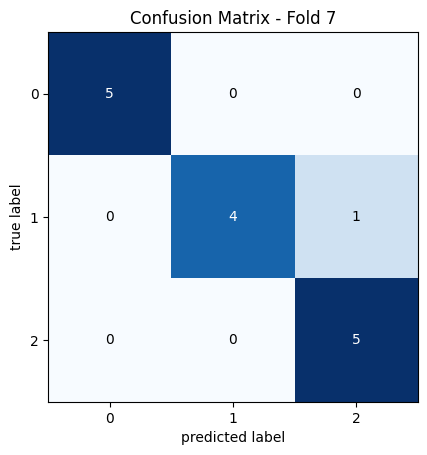


Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         5
Iris-versicolor       1.00      0.80      0.89         5
 Iris-virginica       0.83      1.00      0.91         5

       accuracy                           0.93        15
      macro avg       0.94      0.93      0.93        15
   weighted avg       0.94      0.93      0.93        15



Fold: 8
Accuracy      : 1.0
Precision     : 1.0
Recall        : 1.0
F1 Score      : 1.0

Confusion Matrix:


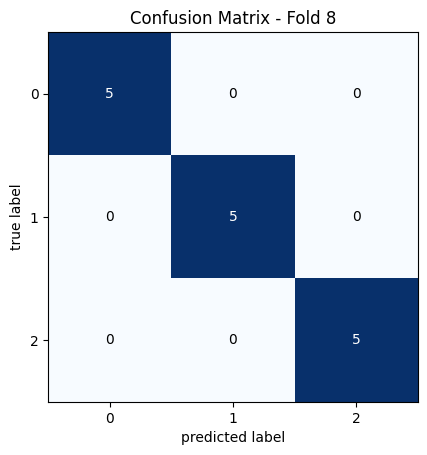


Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         5
Iris-versicolor       1.00      1.00      1.00         5
 Iris-virginica       1.00      1.00      1.00         5

       accuracy                           1.00        15
      macro avg       1.00      1.00      1.00        15
   weighted avg       1.00      1.00      1.00        15



Fold: 9
Accuracy      : 0.8667
Precision     : 0.8667
Recall        : 0.8667
F1 Score      : 0.8667

Confusion Matrix:


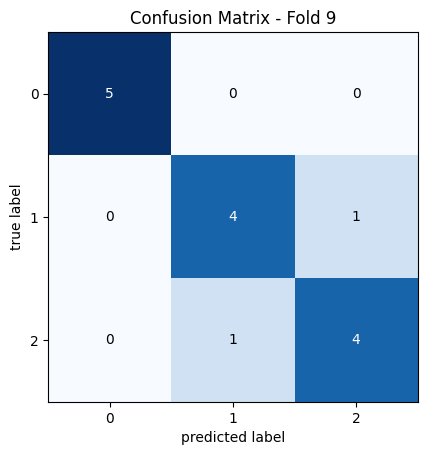


Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         5
Iris-versicolor       0.80      0.80      0.80         5
 Iris-virginica       0.80      0.80      0.80         5

       accuracy                           0.87        15
      macro avg       0.87      0.87      0.87        15
   weighted avg       0.87      0.87      0.87        15



Fold: 10
Accuracy      : 1.0
Precision     : 1.0
Recall        : 1.0
F1 Score      : 1.0

Confusion Matrix:


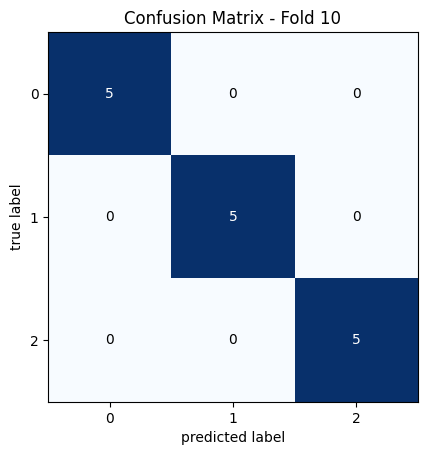


Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         5
Iris-versicolor       1.00      1.00      1.00         5
 Iris-virginica       1.00      1.00      1.00         5

       accuracy                           1.00        15
      macro avg       1.00      1.00      1.00        15
   weighted avg       1.00      1.00      1.00        15

FINAL
Average Accuracy  : 0.96
Average Precision : 0.966
Average Recall    : 0.96
Average F1 Score  : 0.9593


In [107]:
print("\n KNN ")

model_knn = KNeighborsClassifier(n_neighbors=5)
evaluate_model(model_knn, X, Y)


 DECISION TREE


Fold: 1
Accuracy      : 0.8667
Precision     : 0.9048
Recall        : 0.8667
F1 Score      : 0.8611

Confusion Matrix:


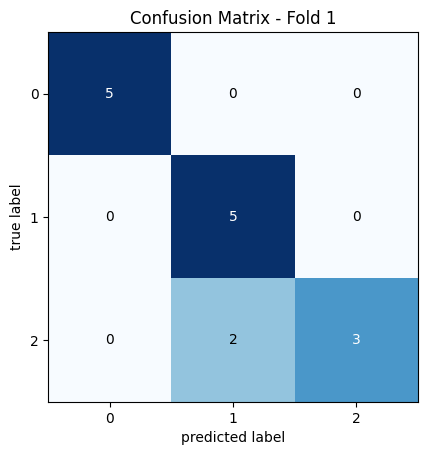


Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         5
Iris-versicolor       0.71      1.00      0.83         5
 Iris-virginica       1.00      0.60      0.75         5

       accuracy                           0.87        15
      macro avg       0.90      0.87      0.86        15
   weighted avg       0.90      0.87      0.86        15



Fold: 2
Accuracy      : 0.8667
Precision     : 0.9048
Recall        : 0.8667
F1 Score      : 0.8611

Confusion Matrix:


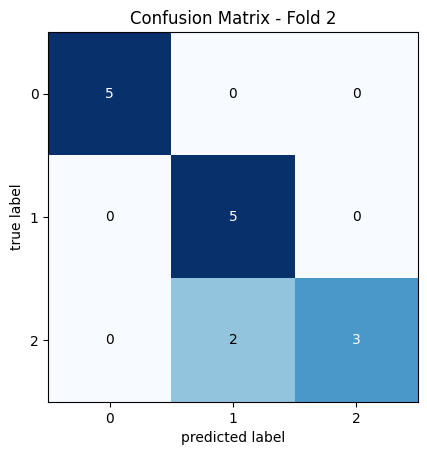


Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         5
Iris-versicolor       0.71      1.00      0.83         5
 Iris-virginica       1.00      0.60      0.75         5

       accuracy                           0.87        15
      macro avg       0.90      0.87      0.86        15
   weighted avg       0.90      0.87      0.86        15



Fold: 3
Accuracy      : 0.9333
Precision     : 0.9444
Recall        : 0.9333
F1 Score      : 0.9327

Confusion Matrix:


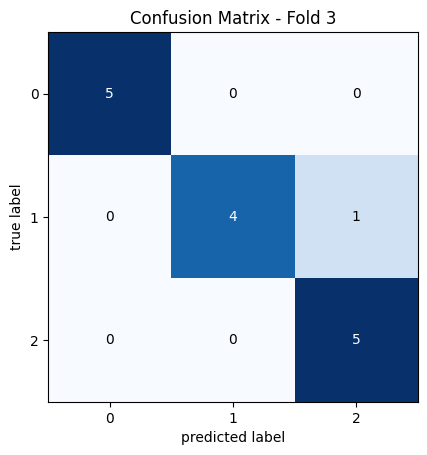


Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         5
Iris-versicolor       1.00      0.80      0.89         5
 Iris-virginica       0.83      1.00      0.91         5

       accuracy                           0.93        15
      macro avg       0.94      0.93      0.93        15
   weighted avg       0.94      0.93      0.93        15



Fold: 4
Accuracy      : 0.9333
Precision     : 0.9444
Recall        : 0.9333
F1 Score      : 0.9327

Confusion Matrix:


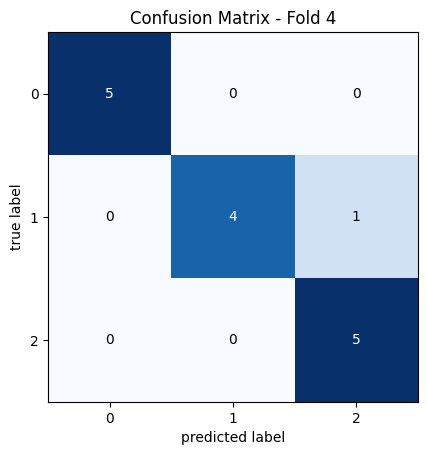


Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         5
Iris-versicolor       1.00      0.80      0.89         5
 Iris-virginica       0.83      1.00      0.91         5

       accuracy                           0.93        15
      macro avg       0.94      0.93      0.93        15
   weighted avg       0.94      0.93      0.93        15



Fold: 5
Accuracy      : 1.0
Precision     : 1.0
Recall        : 1.0
F1 Score      : 1.0

Confusion Matrix:


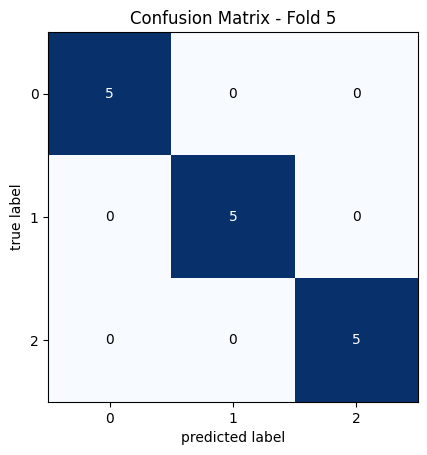


Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         5
Iris-versicolor       1.00      1.00      1.00         5
 Iris-virginica       1.00      1.00      1.00         5

       accuracy                           1.00        15
      macro avg       1.00      1.00      1.00        15
   weighted avg       1.00      1.00      1.00        15



Fold: 6
Accuracy      : 1.0
Precision     : 1.0
Recall        : 1.0
F1 Score      : 1.0

Confusion Matrix:


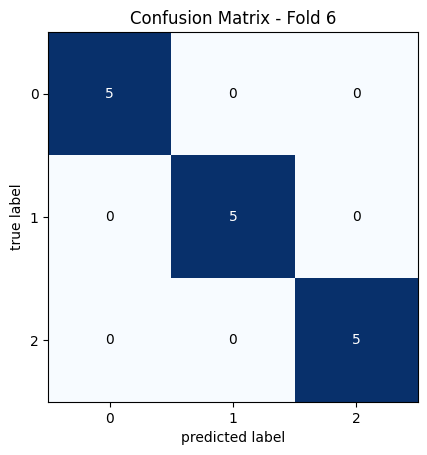


Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         5
Iris-versicolor       1.00      1.00      1.00         5
 Iris-virginica       1.00      1.00      1.00         5

       accuracy                           1.00        15
      macro avg       1.00      1.00      1.00        15
   weighted avg       1.00      1.00      1.00        15



Fold: 7
Accuracy      : 0.9333
Precision     : 0.9444
Recall        : 0.9333
F1 Score      : 0.9327

Confusion Matrix:


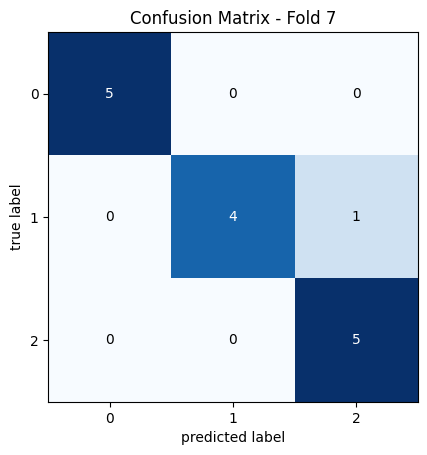


Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         5
Iris-versicolor       1.00      0.80      0.89         5
 Iris-virginica       0.83      1.00      0.91         5

       accuracy                           0.93        15
      macro avg       0.94      0.93      0.93        15
   weighted avg       0.94      0.93      0.93        15



Fold: 8
Accuracy      : 0.9333
Precision     : 0.9444
Recall        : 0.9333
F1 Score      : 0.9327

Confusion Matrix:


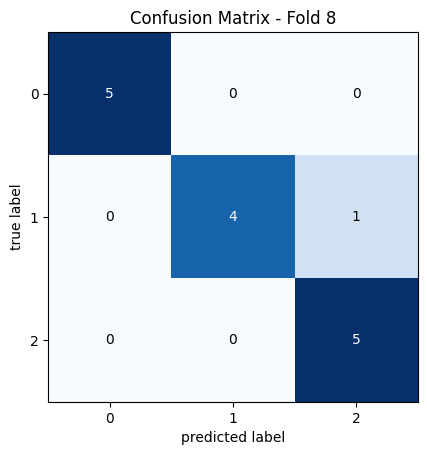


Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         5
Iris-versicolor       1.00      0.80      0.89         5
 Iris-virginica       0.83      1.00      0.91         5

       accuracy                           0.93        15
      macro avg       0.94      0.93      0.93        15
   weighted avg       0.94      0.93      0.93        15



Fold: 9
Accuracy      : 0.8667
Precision     : 0.8667
Recall        : 0.8667
F1 Score      : 0.8667

Confusion Matrix:


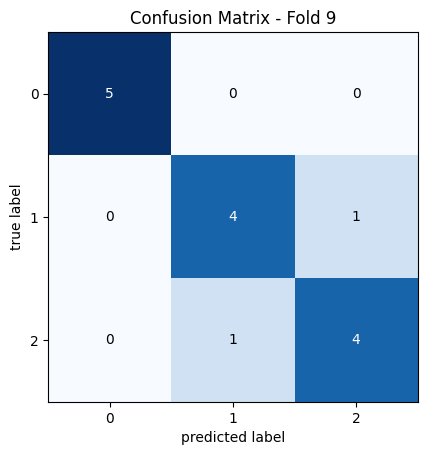


Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         5
Iris-versicolor       0.80      0.80      0.80         5
 Iris-virginica       0.80      0.80      0.80         5

       accuracy                           0.87        15
      macro avg       0.87      0.87      0.87        15
   weighted avg       0.87      0.87      0.87        15



Fold: 10
Accuracy      : 1.0
Precision     : 1.0
Recall        : 1.0
F1 Score      : 1.0

Confusion Matrix:


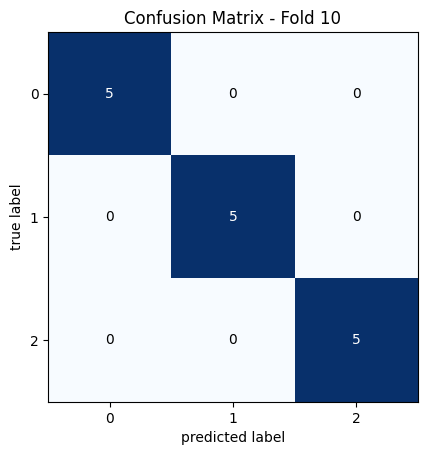


Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         5
Iris-versicolor       1.00      1.00      1.00         5
 Iris-virginica       1.00      1.00      1.00         5

       accuracy                           1.00        15
      macro avg       1.00      1.00      1.00        15
   weighted avg       1.00      1.00      1.00        15

FINAL
Average Accuracy  : 0.9333
Average Precision : 0.9454
Average Recall    : 0.9333
Average F1 Score  : 0.932


In [108]:
print("\n DECISION TREE")

model_dt = DecisionTreeClassifier(criterion='gini')
evaluate_model(model_dt, X, Y)